In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [120]:
df = pd.read_csv("Fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Data Cleaning
1. Dataset size: 6,362,620 rows.
2. No missing values.
3. No duplicate rows.
4. Fraud rate: ~0.13% (highly imbalanced).
5. Merchant accounts do not have destination balance info.
6. Created features: isMerchant, error_balance_dest_clean.
7. Dropped: nameOrig, nameDest, newbalanceOrig, newbalanceDest.

In [121]:
df['isFraud'].value_counts()                  #          8213 - frauds  :(
df['isFlaggedFraud'].value_counts()           #          16  - FlaggedFraud  :(
df.shape                                      #          (6362620, 11)
df.isnull().sum()                             #          0  happy~~  :)
df.duplicated().sum()                         #          0  good data~~  :)


0

In [122]:
df[df['isFraud'] == 1]['nameDest'].str.startswith('M').sum()        #    0 - Merchants are good people. but there transactions are private
df['isMerchant'] = df['nameDest'].str.startswith('M').astype(int)

In [128]:
# Fraud analysis
fraud_by_type = df.groupby('type')['isFraud'].agg(['count','sum'])
fraud_by_type['fraud_percentage'] = (fraud_by_type['sum']/fraud_by_type['count'])*100
fraud_by_type

,count,sum,fraud_percentage
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.183955
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.768799


# Maximum Frauds are done in CASH_OUT and TRANSFER
1. thers are the key insights to detect frauds
2. fraud percentage is more in the TRANSFER

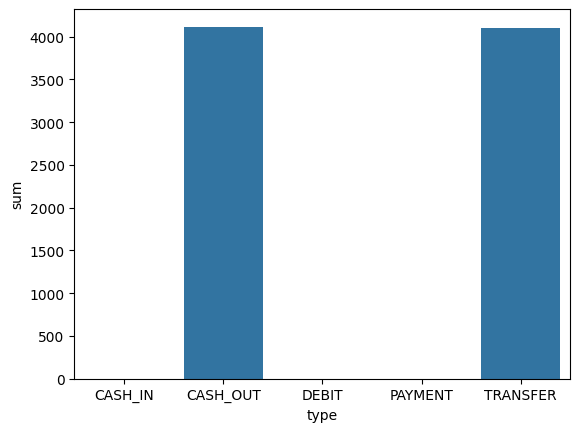

In [90]:
sns.barplot(fraud_by_type, x = "type", y = "sum")
plt.show()

In [91]:
df[df['isFlaggedFraud'] == 1]['isFraud'].value_counts()        # all flaggedfrauds are true  :!

isFraud
1    16
Name: count, dtype: int64

In [130]:
# error rate in the balences
df['error_balance_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['error_balance_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']
df.groupby('isFraud')[['error_balance_orig', 'error_balance_dest']].mean()


,error_balance_orig,error_balance_dest
isFraud,,
0,-201338.558109,-54692.231734
1,-10692.325265,-732509.301069


# these are incorret values
1. error includes the Merchant account
2. Merchent accounts are with no details of trancasction, balance shows 0.
3. So, max error may contribute from the Merchant account.
4. lets exclude the Merchant accounts from the error balance.
5. we get actual error balance

In [132]:
df['error_balance_dest_clean'] = 0

df.loc[df['isMerchant'] == 0, 'error_balance_dest_clean'] = (df['newbalanceDest'] - df['oldbalanceDest'] - df['amount'])


C:\Users\guggi\AppData\Local\Temp\ipykernel_1468\2513600704.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.81000000e+02 -2.13630000e+04 -6.88698000e+03 ... -9.99999978e-03
 -8.50002520e+05 -4.65661287e-10]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['isMerchant'] == 0, 'error_balance_dest_clean'] = (df['newbalanceDest'] - df['oldbalanceDest'] - df['amount'])


In [106]:
df.groupby('isFraud')[['error_balance_orig', 'error_balance_dest_clean']].mean()

,error_balance_orig,error_balance_dest_clean
isFraud,,
0,-201338.558109,-50271.147101
1,-10692.325265,-732509.301069


In [108]:
df.groupby('isFraud')[['error_balance_orig', 'error_balance_dest_clean']].median()


,error_balance_orig,error_balance_dest_clean
isFraud,,
0,-69049.31,0.00
1,0.00,-2231.46


In [134]:
df = df.drop(['nameOrig', 'nameDest', 'error_balance_dest'], axis=1)
df.head()


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,isMerchant,error_balance_orig,error_balance_dest_clean
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,1,1.455192e-11,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,1,-1.136868e-12,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,0,0.000000e+00,-181.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,0,0.000000e+00,-21363.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,1,0.000000e+00,0.0


In [136]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [138]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,isMerchant,error_balance_orig,error_balance_dest_clean,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,1,1.455192e-11,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1,-1.136868e-12,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,0,0.000000e+00,-181.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,0,0.000000e+00,-21363.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,1,0.000000e+00,0.0,False,False,True,False


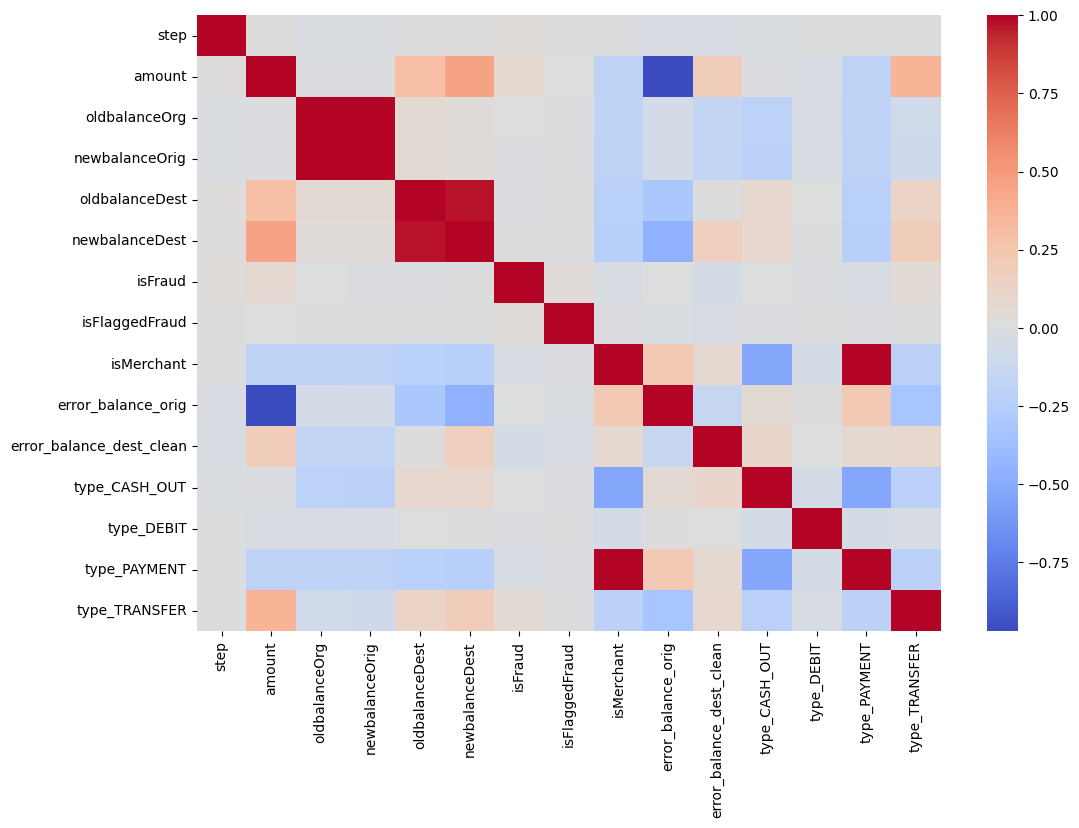

In [146]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [148]:
df.drop(['newbalanceOrig', 'newbalanceDest'], axis=1, inplace=True)

In [158]:
df_sample = df.sample(n=500000, random_state=42)

In [172]:
# Prepare x and y
x = df_sample.drop('isFraud', axis=1)
y = df_sample['isFraud']

In [174]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Model Used
1. Tested Logistic Regression and Random Forest.
2. Logistic Regression: High recall (0.99) but very low precision (0.03).
3. Random Forest: Precision 0.98, Recall 0.75, ROC-AUC 0.98.
4. Final Model Selected: Random Forest.

In [176]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [188]:
rf = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [192]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:,1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_proba_rf))


Confusion Matrix:
[[99869     2]
 [   32    97]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       0.98      0.75      0.85       129

    accuracy                           1.00    100000
   macro avg       0.99      0.88      0.93    100000
weighted avg       1.00      1.00      1.00    100000


ROC-AUC Score:
0.9838603426326938


In [194]:
feature_importance = pd.Series(rf.feature_importances_,index=x_train.columns).sort_values(ascending=False)

print(feature_importance.head(10))


amount                      0.243772
error_balance_dest_clean    0.241785
oldbalanceOrg               0.140219
step                        0.113257
error_balance_orig          0.092833
oldbalanceDest              0.086435
type_TRANSFER               0.053213
type_CASH_OUT               0.023134
isMerchant                  0.002206
type_PAYMENT                0.002049
dtype: float64


# Variable Selection Logic
1. Selected based on business logic and feature importance.
Top variables:
1. amount
2. error_balance_dest_clean
3. oldbalanceOrg
4. step
5. error_balance_orig
6. oldbalanceDes

#  Model Performance
Confusion Matrix (Test Set):
1. True Fraud Detected: 97
2. Fraud Missed: 32
3. False Alarms: 2
Metrics:
1. Precision (Fraud): 0.98
2. Recall (Fraud): 0.75
3. ROC-AUC: 0.9

# Key Factors Predicting Fraud
1. High transaction amount
2. Abnormal destination balance behavior
3. High origin balance
4. Transfer and Cash-Out transactions
5. Time pattern (step)

# Recommended  Prevention Strategy
1. Real-time monitoring of large transfers
2. Flag abnormal balance mismatches
3. Additional authentication for high-value transfers
4. Monitor rapid account draining
5. Freeze suspicious accounts automaticall

# How to Measure Effectiveness
1. Compare fraud rate before vs after
2. Measure financial loss reduction
3. Monitor false positive rate
4. Track investigation cost
5. Monitor model drift over tim